In [ ]:
import STAGATE
import GraphST
import SpaGCN
import warnings
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys

In [27]:
adata = sc.read_h5ad("data/DLPFC_151507_ST_final.h5ad")

print(adata)
print(adata.obsm.keys())
print(adata.uns.keys())

AnnData object with n_obs × n_vars = 4221 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts'
    uns: 'image_cluster_colors', 'log1p', 'spatial'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial'
    obsp: 'adj_f', 'adj_i', 'adj_t'
KeysView(AxisArrays with keys: X_pca, features, features_summary_scale0.5_0.5, features_summary_scale0.5_1, features_summary_scale0.5_2, features_summary_scale1_0.5, features_summary_scale1_1, features_summary_scale1_2, features_summary_scale2_0.5, features_summary_scale2_1, features_summary_scale2_2, spatial)
dict_keys(['image_cluster_colors', 'log1p', 'spatial']

In [54]:
adata.obsm["spatial"]

array([[3276, 2514],
       [9178, 8520],
       [5133, 2878],
       ...,
       [4218, 9703],
       [4017, 7906],
       [5683, 3359]], shape=(4221, 2))

In [11]:
adata = sc.read_h5ad("data/DLPFC_151507_ST_final.h5ad")

print(adata)
print("\nobsm:")
print(adata.obsm.keys())

print("\nspatial shape:")
print(adata.obsm["spatial"].shape)

print("\nHas spatial uns:")
print("spatial" in adata.uns)

if "spatial" in adata.uns:
    print("\nSpatial library IDs:")
    print(adata.uns["spatial"].keys())

AnnData object with n_obs × n_vars = 4221 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts'
    uns: 'image_cluster_colors', 'log1p', 'spatial'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial'
    obsp: 'adj_f', 'adj_i', 'adj_t'

obsm:
KeysView(AxisArrays with keys: X_pca, features, features_summary_scale0.5_0.5, features_summary_scale0.5_1, features_summary_scale0.5_2, features_summary_scale1_0.5, features_summary_scale1_1, features_summary_scale1_2, features_summary_scale2_0.5, features_summary_scale2_1, features_summary_scale2_2, spatial)

spatial shape:
(4221, 2)

Has spatial uns:
Tru

In [12]:
for key in adata.obsp.keys():
    A = adata.obsp[key]

    print(f"\n{key}")
    print("shape:", A.shape)
    print("type:", type(A))

    if hasattr(A, "nnz"):
        print("non-zero entries:", A.nnz)


adj_f
shape: (4221, 4221)
type: <class 'scipy.sparse._csr.csr_matrix'>
non-zero entries: 101264

adj_i
shape: (4221, 4221)
type: <class 'numpy.ndarray'>

adj_t
shape: (4221, 4221)
type: <class 'numpy.ndarray'>


In [14]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import numpy as np

def build_knn_graph(adata, k=6):

    coords = adata.obsm["spatial"]

    nbrs = NearestNeighbors(
        n_neighbors=k + 1
    ).fit(coords)

    distances, indices = nbrs.kneighbors(coords)

    # Remove self-neighbor
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    n = coords.shape[0]

    rows = np.repeat(np.arange(n), k)
    cols = indices.reshape(-1)

    data = np.ones(len(rows))

    A = csr_matrix(
        (data, (rows, cols)),
        shape=(n, n)
    )

    # Make graph undirected
    A = A.maximum(A.T)

    return A, distances, indices



def graph_statistics(A):

    A = A.tocsr()

    n = A.shape[0]
    edges_directed = A.nnz

    # Assuming an undirected graph
    edges = edges_directed // 2

    degrees = np.asarray(A.sum(axis=1)).flatten()

    density = edges / (n * (n - 1) / 2)

    stats = {
        "nodes": n,
        "edges": edges,
        "average_degree": degrees.mean(),
        "min_degree": degrees.min(),
        "max_degree": degrees.max(),
        "density": density
    }

    return stats

In [ ]:
for key in adata.obsp.keys():
    A = adata.obsp[key]

    print(f"\n{key}")
    print("shape:", A.shape)
    print("type:", type(A))

    if hasattr(A, "nnz"):
        print("non-zero entries:", A.nnz)

A_knn, distances, indices = build_knn_graph(adata, k=6)
print(graph_statistics(A_knn))


adj_f
shape: (4221, 4221)
type: <class 'scipy.sparse._csr.csr_matrix'>
non-zero entries: 101264

adj_i
shape: (4221, 4221)
type: <class 'numpy.ndarray'>

adj_t
shape: (4221, 4221)
type: <class 'numpy.ndarray'>
{'nodes': 4221, 'edges': 12895, 'average_degree': np.float64(6.109926557687752), 'min_degree': np.float64(6.0), 'max_degree': np.float64(9.0), 'density': 0.001447849895186671}


We now know your simple coordinate-based kNN graph with k=6 has:

4,221 nodes
12,895 undirected edges
Average degree ≈ 6.11
Degree range 6–9
Density ≈ 0.145%

That looks exactly like a fairly local spatial graph.

In [16]:
A = adata.obsp["adj_f"]

print("shape:", A.shape)
print("nnz:", A.nnz)

# Check whether symmetric
diff = A - A.T
print("symmetric:", diff.nnz == 0)

# Degree
degrees = np.asarray(A.sum(axis=1)).flatten()

print("degree min:", degrees.min())
print("degree max:", degrees.max())
print("degree mean:", degrees.mean())

# Values
values = A.data

print("value min:", values.min())
print("value max:", values.max())

print("first 20 values:")
print(values[:20])

shape: (4221, 4221)
nnz: 101264
symmetric: True
degree min: 3.9068806
degree max: 101.56641
degree mean: 7.152006
value min: 4.350945e-06
value max: 1.0
first 20 values:
[0.05251898 0.17922464 0.08127489 0.54006344 0.0727374  0.9116802
 1.         0.08668281 0.29985288 0.08272038 0.07040082 0.13974988
 0.07866455 0.31131425 0.7888636  0.12908307 0.99999994 0.9667999
 0.25630885 0.27402878]


In [17]:
for key in ["adj_i", "adj_t"]:

    A = np.asarray(adata.obsp[key])

    print(f"\n===== {key} =====")

    print("shape:", A.shape)

    print("symmetric:", np.allclose(A, A.T))

    print("non-zero:", np.count_nonzero(A))

    print("min:", A.min())
    print("max:", A.max())

    degrees = np.count_nonzero(A, axis=1)

    print("degree min:", degrees.min())
    print("degree max:", degrees.max())
    print("degree mean:", degrees.mean())


===== adj_i =====
shape: (4221, 4221)
symmetric: True
non-zero: 77631
min: 0.0
max: 1.0
degree min: 0
degree max: 53
degree mean: 18.391613361762616

===== adj_t =====
shape: (4221, 4221)
symmetric: True
non-zero: 29167
min: 0.0
max: 1.0
degree min: 3
degree max: 9
degree mean: 6.909973939824686


Ah, this is very interesting. Those three matrices are telling us that your .h5ad already contains several different notions of neighborhood, and we should not use them as the STAGATE/GraphST/SpaGCN benchmark yet.

What your matrices look like
Matrix	Nonzero	Avg. degree	Values	Interpretation
adj_f	101,264	~7.15 weighted sum	0 → 1	Weighted graph
adj_i	77,631	~18.39	0/1	Binary, much denser graph
adj_t	29,167	~6.91	0/1	Binary, local graph
Our kNN-6	~25,790 directed / 12,895 undirected	~6.11	0/1	Simple coordinate kNN

A particularly interesting observation is that adj_t is very close to our simple spatial kNN graph in density:

adj_t: average degree ≈ 6.91
our kNN-6: average degree ≈ 6.11

So adj_t may be some form of local tissue/spatial adjacency, whereas adj_i is substantially broader.

But adj_f is different again: it has ~101k nonzero entries but its values are continuous. That's clearly not simply "connect the six nearest spots."

adj_f isn't just a graph telling us who is connected. It also tells us how strongly connected two spots are.

In [18]:

print("STAGATE:", dir(STAGATE))
print("\nGraphST:", dir(GraphST))
print("\nSpaGCN:", dir(SpaGCN))

STAGATE: ['Cal_Spatial_Net', 'Cal_Spatial_Net_3D', 'STAGATE', 'Stats_Spatial_Net', 'Train_STAGATE', '__author__', '__builtins__', '__cached__', '__doc__', '__email__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'mclust_R', 'model', 'train_STAGATE', 'utils']

GraphST: ['__author__', '__builtins__', '__cached__', '__doc__', '__email__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'add_contrastive_label', 'clustering', 'construct_interaction', 'fix_seed', 'get_feature', 'permutation', 'preprocess', 'preprocess_adj', 'project_cell_to_spot', 'utils']

SpaGCN: ['AnnData', 'F', 'GC_DEC', 'Geary_C', 'GraphConvolution', 'KMeans', 'Module', 'Moran_I', 'NearestNeighbors', 'PCA', 'Parameter', 'SpaGCN', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculate_adj', 'calculate_adj_matrix', 'calculate_moran_I', 'calculate_p', 'clr', 'count_nbr', 'cs

### STAGATE

In [3]:
import STAGATE

def get_stagate_graph(adata, k=6):

    adata_tmp = adata.copy()

    STAGATE.Cal_Spatial_Net(
        adata_tmp,
        k_cutoff=k,
        model="KNN",
        verbose=False
    )

    spatial_net = adata_tmp.uns["Spatial_Net"]

    return spatial_net

In [6]:
stagate_net = get_stagate_graph(adata)

print(stagate_net.head())
print(stagate_net.shape)

                       Cell1                      Cell2    Distance
1  AAACAACGAATAGTTC-1_151507  TAACCGTCCAGTTCAT-1_151507  137.557261
2  AAACAACGAATAGTTC-1_151507  CAAGGGAGTGTATTTG-1_151507  137.927517
3  AAACAACGAATAGTTC-1_151507  CCAAGCTTGATCTCCT-1_151507  138.000000
4  AAACAACGAATAGTTC-1_151507  GGGTTTCCGGCTTCCA-1_151507  138.003623
5  AAACAACGAATAGTTC-1_151507  TTATTTCATCCCAAAC-1_151507  238.403020
(25326, 3)


### GraphST

In [7]:
GraphST.construct_interaction(adata, n_neighbors=3)

In [8]:
adata.obsm["graph_neigh"]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4221, 4221))

In [9]:
adata.obsm["adj"]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4221, 4221))

In [ ]:
adj = adj + adj.T
adj = np.where(adj > 1, 1, adj)

In [11]:
import GraphST

def get_graphst_graph(adata, k=3):

    adata_tmp = adata.copy()

    GraphST.construct_interaction(
        adata_tmp,
        n_neighbors=k
    )

    return adata_tmp.obsm["adj"]

def construct_graphst_graph(adata, n_neighbors=3):

    adata_tmp = adata.copy()

    GraphST.construct_interaction(
        adata_tmp,
        n_neighbors=n_neighbors
    )

    # GraphST stores the final symmetric adjacency matrix here
    adj = np.asarray(adata_tmp.obsm["adj"])

    return adj

In [12]:
graphst_adj = get_graphst_graph(adata, k=3)

print(graphst_adj.shape)
print(np.count_nonzero(graphst_adj))

(4221, 4221)
14496


### SpaGCN

In [13]:
import SpaGCN

coords = adata.obsm["spatial"]

x = coords[:, 0].tolist()
y = coords[:, 1].tolist()

spagcn_dist = SpaGCN.calculate_adj_matrix(
    x=x,
    y=y,
    histology=False
)

print(spagcn_dist.shape)
print(spagcn_dist.min())
print(spagcn_dist.max())

Calculateing adj matrix using xy only...
(4221, 4221)
0.0
10889.727


### Comparison

In [14]:
# STAGATE
stagate_net = get_stagate_graph(adata)

print("STAGATE")
print(stagate_net.shape)
print(stagate_net.head())

STAGATE
(25326, 3)
                       Cell1                      Cell2    Distance
1  AAACAACGAATAGTTC-1_151507  TAACCGTCCAGTTCAT-1_151507  137.557261
2  AAACAACGAATAGTTC-1_151507  CAAGGGAGTGTATTTG-1_151507  137.927517
3  AAACAACGAATAGTTC-1_151507  CCAAGCTTGATCTCCT-1_151507  138.000000
4  AAACAACGAATAGTTC-1_151507  GGGTTTCCGGCTTCCA-1_151507  138.003623
5  AAACAACGAATAGTTC-1_151507  TTATTTCATCCCAAAC-1_151507  238.403020


In [15]:
# GraphST
graphst_adj = get_graphst_graph(adata, k=3)

print("GraphST")
print(graphst_adj.shape)
print("Non-zero:", np.count_nonzero(graphst_adj))

GraphST
(4221, 4221)
Non-zero: 14496


In [16]:
# SpaGCN coordinate-only
coords = adata.obsm["spatial"]

spagcn_dist = SpaGCN.calculate_adj_matrix(
    x=coords[:, 0].tolist(),
    y=coords[:, 1].tolist(),
    histology=False
)

print("SpaGCN")
print(spagcn_dist.shape)
print("Min:", spagcn_dist.min())
print("Max:", spagcn_dist.max())

Calculateing adj matrix using xy only...
SpaGCN
(4221, 4221)
Min: 0.0
Max: 10889.727


What we have for DLPFC 151507
Method	Construction	Result	Interpretation
STAGATE	kNN, k=3	12,663 edges	Exactly 3 neighbors per spot
GraphST	kNN, k=3 + symmetrization	14,496 edges	Some spots become mutual neighbors
SpaGCN	Pairwise Euclidean distance	4,221 × 4,221 matrix	Not yet a graph

The STAGATE number is particularly neat:

4,221 × 3 = 12,663

In [34]:
import inspect

print(inspect.signature(SpaGCN.calculate_p))
print(inspect.getsource(SpaGCN.calculate_p))

(adj, l)
def calculate_p(adj, l):
    adj_exp=np.exp(-1*(adj**2)/(2*(l**2)))
    return np.mean(np.sum(adj_exp,1))-1



stagate: coordinates
    ↓
K nearest neighbors
    ↓
binary edges
graphst: coordinates
    ↓
K nearest neighbors
    ↓
symmetrization
    ↓
binary edges
spagcn: coordinates
      ↓
Euclidean distance
      ↓
Gaussian kernel
      ↓
weighted graph

with histology: coordinates + image-derived feature
              ↓
       Euclidean distance
              ↓
        Gaussian kernel
              ↓
        weighted graph

### Neighbors

In [17]:
def get_stagate_neighbors(spatial_net):
    neighbors = {}

    for _, row in spatial_net.iterrows():
        cell1 = row["Cell1"]
        cell2 = row["Cell2"]

        if cell1 not in neighbors:
            neighbors[cell1] = set()

        neighbors[cell1].add(cell2)

    return neighbors

cell_to_idx = {
    cell: i
    for i, cell in enumerate(adata.obs_names)
}

In [18]:
stagate_neighbors = {}

for _, row in stagate_net.iterrows():

    i = cell_to_idx[row["Cell1"]]
    j = cell_to_idx[row["Cell2"]]

    if i not in stagate_neighbors:
        stagate_neighbors[i] = set()

    stagate_neighbors[i].add(j)

In [19]:
graphst_adj = construct_graphst_graph(
    adata,
    n_neighbors=3
)
graphst_neighbors = {
    i: set(np.where(graphst_adj[i] > 0)[0])
    for i in range(graphst_adj.shape[0])
}
overlaps = []

for i in range(adata.n_obs):

    A = stagate_neighbors.get(i, set())
    B = graphst_neighbors.get(i, set())

    if len(A | B) > 0:
        jaccard = len(A & B) / len(A | B)
        overlaps.append(jaccard)

print("Mean Jaccard overlap:", np.mean(overlaps))
print("Median Jaccard overlap:", np.median(overlaps))

Mean Jaccard overlap: 0.5720828961767128
Median Jaccard overlap: 0.5


In [20]:
l = SpaGCN.search_l(
    0.5,
    spagcn_dist
)

print("l =", l)

Run 1: l [0.01, 1000], p [0.0, 312.04922]
Run 2: l [0.01, 500.005], p [0.0, 85.54007]
Run 3: l [0.01, 250.0075], p [0.0, 21.697504]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.812828]
Run 5: l [0.01, 62.509375], p [0.0, 0.517257]
Run 6: l [31.2596875, 62.509375], p [0.00034475327, 0.517257]
Run 7: l [46.884531249999995, 62.509375], p [0.07717371, 0.517257]
Run 8: l [54.69695312499999, 62.509375], p [0.2438227, 0.517257]
Run 9: l [58.6031640625, 62.509375], p [0.36827576, 0.517257]
Run 10: l [60.556269531249995, 62.509375], p [0.43989897, 0.517257]
Run 11: l [61.532822265625, 62.509375], p [0.47788703, 0.517257]
recommended l =  62.021098632812496
l = 62.021098632812496


In [21]:
spagcn_weight = np.exp(
    -(spagcn_dist ** 2) / (2 * l ** 2)
)

In [22]:
print("Shape:", spagcn_weight.shape)
print("Min:", spagcn_weight.min())
print("Max:", spagcn_weight.max())

Shape: (4221, 4221)
Min: 0.0
Max: 1.0


In [ ]:
sections = ["151507", "151508", "151509", "151510", "151669", "151670", "151671", "151672", "151673", "151674", "151675", "151676"]
adata_section = []
for section in sections:
    adata = sc.read_h5ad(
        f"data/DLPFC_{section}_ST_final.h5ad"
    )
    adata_section.append(adata)

print(adata_section)

## Visualization

In [29]:
stagate_graph = get_stagate_graph(adata)
n = adata.n_obs

stagate_adj = np.zeros((n, n), dtype=int)

for _, row in stagate_graph.iterrows():
    i = adata.obs_names.get_loc(row["Cell1"])
    j = adata.obs_names.get_loc(row["Cell2"])

    stagate_adj[i, j] = 1
    stagate_adj[j, i] = 1

graphst_adj = get_graphst_graph(adata, k=3)

coords = np.asarray(adata.obsm["spatial"])

x = coords[:, 0].tolist()
y = coords[:, 1].tolist()

spagcn_dist = SpaGCN.calculate_adj_matrix(
    x=x,
    y=y,
    histology=False
)

l = SpaGCN.search_l(0.5, spagcn_dist)

spagcn_adj = np.exp(
    -(spagcn_dist ** 2) / (2 * l ** 2)
)

Calculateing adj matrix using xy only...
Run 1: l [0.01, 1000], p [0.0, 312.04922]
Run 2: l [0.01, 500.005], p [0.0, 85.54007]
Run 3: l [0.01, 250.0075], p [0.0, 21.697504]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.812828]
Run 5: l [0.01, 62.509375], p [0.0, 0.517257]
Run 6: l [31.2596875, 62.509375], p [0.00034475327, 0.517257]
Run 7: l [46.884531249999995, 62.509375], p [0.07717371, 0.517257]
Run 8: l [54.69695312499999, 62.509375], p [0.2438227, 0.517257]
Run 9: l [58.6031640625, 62.509375], p [0.36827576, 0.517257]
Run 10: l [60.556269531249995, 62.509375], p [0.43989897, 0.517257]
Run 11: l [61.532822265625, 62.509375], p [0.47788703, 0.517257]
recommended l =  62.021098632812496


In [30]:
print(coords.shape)
print(stagate_adj.shape)
print(graphst_adj.shape)
print(spagcn_adj.shape)

(4221, 2)
(4221, 4221)
(4221, 4221)
(4221, 4221)


In [32]:
def adj_to_edges(adj):
    rows, cols = np.where(adj > 0)
    mask = rows < cols
    return list(zip(rows[mask], cols[mask]))


def top_k_edges(adj, k=3):
    edges = []

    for i in range(adj.shape[0]):
        row = adj[i].copy()
        row[i] = -np.inf

        neighbors = np.argsort(row)[-k:]

        for j in neighbors:
            if i < j:
                edges.append((i, j))

    return edges


stagate_edges = adj_to_edges(stagate_adj)
graphst_edges = adj_to_edges(graphst_adj)
spagcn_edges = top_k_edges(spagcn_adj, k=6)

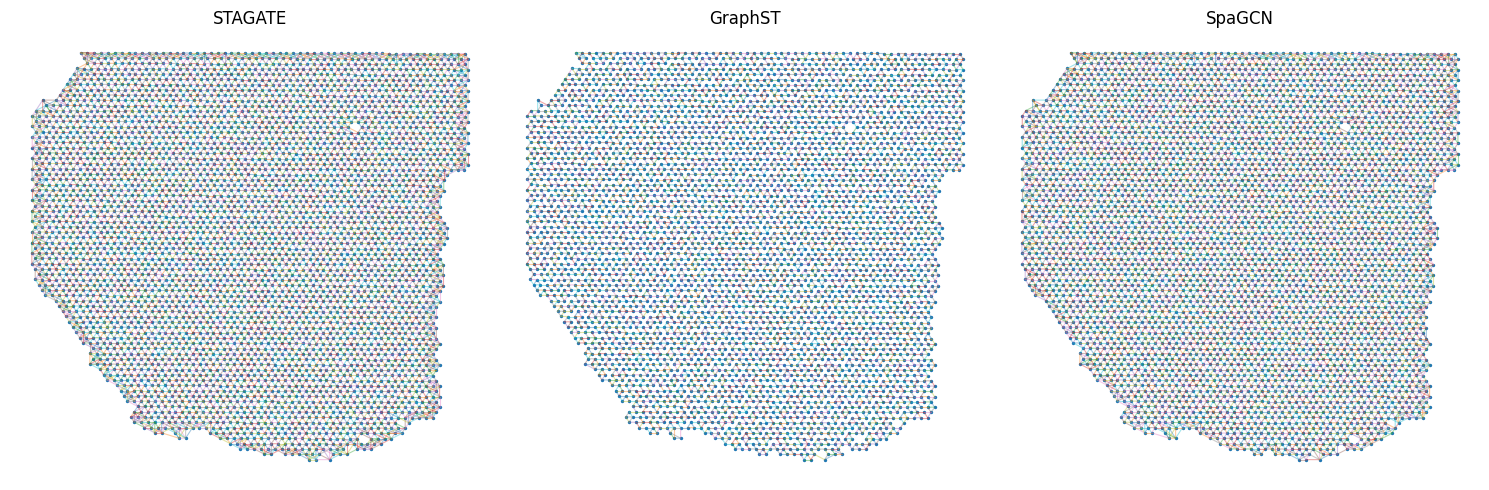

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_graph(ax, coords, edges, title, xlim=None, ylim=None):

    for i, j in edges:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            linewidth=0.8,
            alpha=0.4
        )

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=2
    )

    ax.set_title(title)
    ax.invert_yaxis()
    ax.axis("off")

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)


coords = np.asarray(adata.obsm["spatial"])

# Convert binary adjacency matrices to edges
def adj_to_edges(adj):
    rows, cols = np.where(adj > 0)
    mask = rows < cols
    return list(zip(rows[mask], cols[mask]))

stagate_edges = adj_to_edges(stagate_adj)
graphst_edges = adj_to_edges(graphst_adj)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

plot_graph(
    axes[0],
    coords,
    stagate_edges,
    "STAGATE"
)

plot_graph(
    axes[1],
    coords,
    graphst_edges,
    "GraphST"
)

plot_graph(
    axes[2],
    coords,
    spagcn_edges,
    "SpaGCN"
)

plt.tight_layout()
plt.savefig(
    "151507_graph_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Focused

In [35]:
# Number of common neighbors / union neighbors for each spot
intersection = np.sum(
    (stagate_adj > 0) & (graphst_adj > 0),
    axis=1
)

union = np.sum(
    (stagate_adj > 0) | (graphst_adj > 0),
    axis=1
)

jaccard_per_spot = intersection / np.maximum(union, 1)

# Spots with lowest agreement
worst_spots = np.argsort(jaccard_per_spot)[:100]

print("Lowest-Jaccard spots:")
print(worst_spots[:20])
print("Jaccard:", jaccard_per_spot[worst_spots[:20]])
coords = np.asarray(adata.obsm["spatial"])

x = coords[worst_spots, 0]
y = coords[worst_spots, 1]

print("x range:", x.min(), x.max())
print("y range:", y.min(), y.max())
margin = 100

xlim = (x.min() - margin, x.max() + margin)
ylim = (y.min() - margin, y.max() + margin)

print(xlim, ylim)

Lowest-Jaccard spots:
[ 210 4039 3054 3958  575 1217 2407 1200 2745 1704  810  854 4194 2739
  280  955  957   59 3675  535]
Jaccard: [0.33333333 0.33333333 0.375      0.375      0.375      0.375
 0.375      0.375      0.375      0.375      0.375      0.375
 0.375      0.375      0.375      0.375      0.375      0.375
 0.375      0.375     ]
x range: 2162 10916
y range: 2536 11512
(np.int64(2062), np.int64(11016)) (np.int64(2436), np.int64(11612))


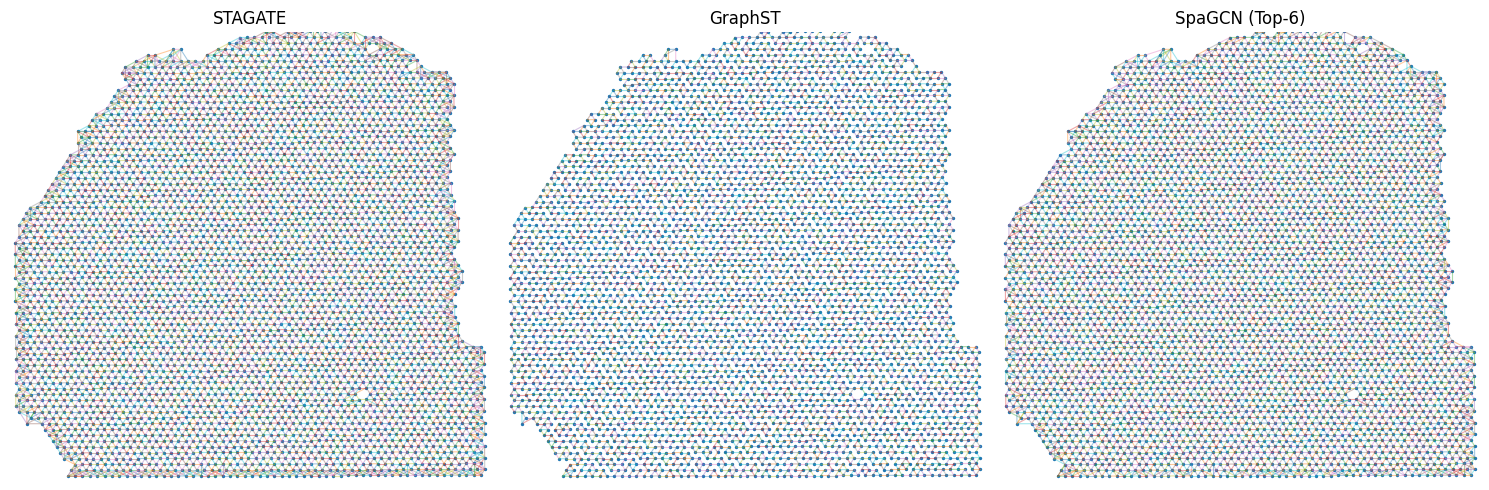

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_graph(
    axes[0], coords, stagate_edges, "STAGATE",
    xlim=xlim, ylim=ylim
)

plot_graph(
    axes[1], coords, graphst_edges, "GraphST",
    xlim=xlim, ylim=ylim
)

plot_graph(
    axes[2], coords, spagcn_edges, "SpaGCN (Top-6)",
    xlim=xlim, ylim=ylim
)

plt.tight_layout()
plt.show()

In [38]:
def plot_graph_disagreement(
    ax,
    coords,
    adj1,
    adj2,
    title,
    jaccard_threshold=0.7
):
    # Find Jaccard similarity for each spot
    intersection = np.sum(
        (adj1 > 0) & (adj2 > 0),
        axis=1
    )

    union = np.sum(
        (adj1 > 0) | (adj2 > 0),
        axis=1
    )

    jaccard = intersection / np.maximum(union, 1)

    # Select the most disagreeing spots
    selected = np.where(jaccard <= jaccard_threshold)[0]

    # Find edges
    e1 = set(
        (min(i, j), max(i, j))
        for i, j in zip(*np.where(np.triu(adj1 > 0, 1)))
    )

    e2 = set(
        (min(i, j), max(i, j))
        for i, j in zip(*np.where(np.triu(adj2 > 0, 1)))
    )

    shared = e1 & e2
    only_1 = e1 - e2
    only_2 = e2 - e1

    # Only show edges involving selected spots
    selected = set(selected)

    def relevant(edge):
        return edge[0] in selected or edge[1] in selected

    shared = [e for e in shared if relevant(e)]
    only_1 = [e for e in only_1 if relevant(e)]
    only_2 = [e for e in only_2 if relevant(e)]

    # Shared edges
    for i, j in shared:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            linewidth=0.5,
            alpha=0.2
        )

    # Only graph 1
    for i, j in only_1:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            linewidth=1.0,
            alpha=0.8
        )

    # Only graph 2
    for i, j in only_2:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            linewidth=1.0,
            alpha=0.8
        )

    # Plot selected spots
    selected = list(selected)

    ax.scatter(
        coords[selected, 0],
        coords[selected, 1],
        s=10
    )

    ax.set_title(title)
    ax.invert_yaxis()
    ax.axis("off")

    print("Selected spots:", len(selected))
    print("Shared edges:", len(shared))
    print("Graph 1 only:", len(only_1))
    print("Graph 2 only:", len(only_2))

Selected spots: 4131
Shared edges: 7235
Graph 1 only: 5646
Graph 2 only: 0


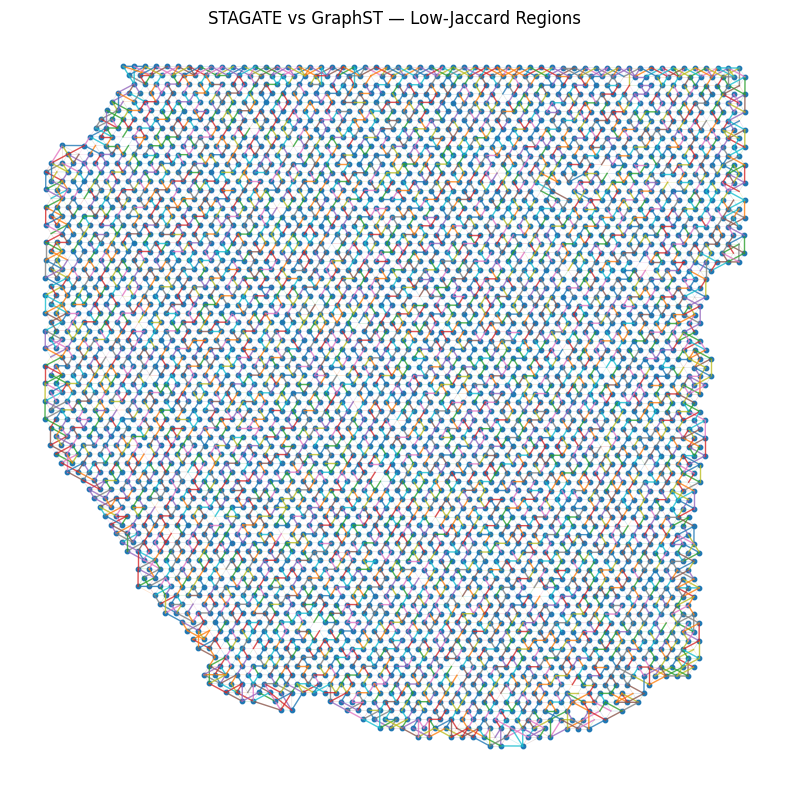

In [39]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

plot_graph_disagreement(
    ax,
    coords,
    stagate_adj,
    graphst_adj,
    "STAGATE vs GraphST — Low-Jaccard Regions",
    jaccard_threshold=0.7
)

plt.tight_layout()
plt.show()